# STA437 FINAL PROJECT CODES
### Zixiang Zhang

This JupiterNotebook demonstrated the codes I used to conduct the experiment in my essay "Unveiling Structural Linear Dependencies Of Handwritten Digits".

Detailed comments are in each function. Recommended process to use these codes are:

1. run the import chunk
2. run the function chunk
3. run full analysis in the third chunk, uncomment lines that did specific task in the line.

### 1. Import and Loading mnist.csv

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

DATA_PATH = "mnist.csv" # please put mnist with code in the same folder.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
if not os.path.exists("plots"):
    os.makedirs("plots")

### 2. Customized Functions

Running this chunk will run all the functions that used in the experiment. You may expand each function to see the comments and usages I wrote inside.

- To use them and perform specific task, input their name and run it in another chunk

- To run all of them that simulates the process described in the methology part of my essay, use funtcion run_full_analysis.

Note that as a lot of the images are selected randomly, it may be hard to find the exact matched image of those I used in my essay. However, the behaviour is as described and ready for you to verify.

In [19]:
def load_data_global(path, sample_size=None):
    """
    Load data from mnist.csv
    """
    if not os.path.exists(path):
        print(f"Error: {path} not found.")
        return None, None

    df = pd.read_csv(path)

    if sample_size and len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    print(f"Data Loaded. Shape: {X.shape}")
    return X, y

def get_image_splits(X_input, mode='LR', img_size=28):
    """
    Image splitting logic:

    mode: 'LR' - Left / Right Split
    mode: 'TB' - Top / Bottom Split
    mode: '4way' - Top Bottom / Left / Right Split all together
    """
    n_samples = X_input.shape[0]
    cut = img_size // 2
    X_img = X_input.reshape(n_samples, img_size, img_size)

    splits = {}

    if mode in ['LR', '4Way']:
        splits['Left'] = X_img[:, :, :cut].reshape(n_samples, -1)
        splits['Right'] = X_img[:, :, cut:].reshape(n_samples, -1)

    if mode in ['TB', '4Way']:
        splits['Top'] = X_img[:, :cut, :].reshape(n_samples, -1)
        splits['Bottom'] = X_img[:, cut:, :].reshape(n_samples, -1)

    return splits

def compute_pca_cca_pipeline(X1, X2, n_components):
    """
    PCA -> CCA Algorithm
    n_components: number of components
    X1: one side of image of a given dividing algorithm
    X2: other side of image of the same dividing algorithm as X1
    """
    try:
        # 1. PCA
        pca1 = PCA(n_components=n_components, random_state=42)
        pca2 = PCA(n_components=n_components, random_state=42)
        X1_pca = pca1.fit_transform(X1)
        X2_pca = pca2.fit_transform(X2)

        # 2. CCA
        cca = CCA(n_components=1)
        cca.fit(X1_pca, X2_pca)
        U, V = cca.transform(X1_pca, X2_pca)
        corr = np.corrcoef(U[:, 0], V[:, 0])[0, 1]

        return {
            'corr': corr,
            'pca1': pca1, 'pca2': pca2,
            'cca': cca,
            'w1': cca.x_weights_[:, 0],  # X1 Weight
            'w2': cca.y_weights_[:, 0]  # X2 Weight
        }
    except Exception as e:
        print(f"Pipeline Error: {e}")
        return None

def visualize_cca_geometry(X, y, n_components, mode='LR'):
    """
    Run CCA visualizations based on the mode selected.

    mode: 'LR' - Left / Right Split
    mode: 'TB' - Top / Bottom Split
    mode: '4way' - Top Bottom / Left / Right Split all together

    """
    print(f"\n--- Running CCA Geometry Analysis (Mode: {mode}, PCs={n_components}) ---")

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    axes = axes.flatten()
    cmap = 'seismic'

    key1, key2 = ('Left', 'Right') if mode == 'LR' else ('Top', 'Bottom')

    img_size = 28
    cut = 14

    for digit in range(10):
        # 1. Data normalization
        X_digit = X[y == digit] / 255.0
        splits = get_image_splits(X_digit, mode=mode) # get_image_splits is a
                                        # custom defined function, see previous chunk.

        # 2. performing compute_pca_cca_pipeline. This function has been defined on previous chunk.
        res = compute_pca_cca_pipeline(splits[key1], splits[key2], n_components)

        cca_img = np.zeros((img_size, img_size))
        corr = 0

        if res:
            corr = res['corr']
            # Back-projection
            # pattern = Weight * PCA_Components
            pat1 = np.dot(res['w1'], res['pca1'].components_)
            pat2 = np.dot(res['w2'], res['pca2'].components_)

            # Stick two matrix together
            if mode == 'LR':
                cca_img[:, :cut] = pat1.reshape(28, 14)
                cca_img[:, cut:] = pat2.reshape(28, 14)
            else:  # mode == 'TB'
                cca_img[:cut, :] = pat1.reshape(14, 28)
                cca_img[cut:, :] = pat2.reshape(14, 28)

        # 3. Draw Visualizations
        ax = axes[digit]
        v_max = np.max(np.abs(cca_img)) if np.max(np.abs(cca_img)) > 0 else 1
        ax.imshow(cca_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.axis('off')
        ax.set_title(f"Digit {digit}\nρ = {corr:.3f}", fontsize=12, fontweight='bold')
        ax.text(0.5, -0.1, f"Mode: {mode}", transform=ax.transAxes, ha='center', fontsize=9, color='gray')

    plt.suptitle(f"CCA Geometry: {mode} Correlation Patterns (Top {n_components} PCs)", fontsize=16)
    plt.tight_layout()
    plt.show()

def verify_variance_coverage(X, y, n_components):
    """
    Verifying the variance explained by n_components PCAs.
    Normally, this number is set to 5. In my essay, it's set to 20 and 5,
    to demonstrate that the image data is highly redundant and showing that
    around 50% of the variance could be explained by first 5 PCs, and around 80%
    of the variance could be explained by first 20 PCs.
    """
    print(f"\n--- Variance Verification (Top {n_components} PCs) ---")
    data = []

    for digit in range(10):
        X_digit = X[y == digit] / 255.0
        splits = get_image_splits(X_digit, mode='4Way')  # Splitting image into 4 parts
                                                        # get_image_splits is a customized function

        # Unless n_components += 5, the following loop calculates the first 5 PCs' variance explained
        # corrospond to their own parts. The loop will find each of them and merge into a summary table.

        row = {"Digit": digit}
        for key in ['Left', 'Right', 'Top', 'Bottom']:
            pca = PCA(n_components=n_components, random_state=42)
            pca.fit(splits[key])
            row[f"{key}_Var"] = np.sum(pca.explained_variance_ratio_)

        data.append(row)

    df = pd.DataFrame(data)
    print(df.set_index("Digit").applymap(lambda x: f"{x:.1%}").to_markdown())
    print(f"Average Variance (Left): {df['Left_Var'].mean():.1%}")

def inspect_cca_weights_unified(X, y, target_digit, n_components, mode='TB'):
    """
    this function will implement the weight of CCA of a given segment of picture by visualizing them in barplot.
    normally, only 5 PCs will be displayed unless otherwise defined.
    """

    print(f"\n=== CCA Weight Inspection: Digit {target_digit}, Mode {mode} ===")

    # 1. partitioning
    X_digit = X[y == target_digit] / 255.0
    splits = get_image_splits(X_digit, mode=mode)
    key1, key2 = ('Left', 'Right') if mode == 'LR' else ('Top', 'Bottom')

    # 2. Using compute_pca_cca_pipeline to perform calculation of weight, two parts will
    #      be assigned to w1 and w2 respectively.

    res = compute_pca_cca_pipeline(splits[key1], splits[key2], n_components)
    if not res: return

    w1, w2 = res['w1'], res['w2']

    # 3. print a short summery of the dominant PC
    dom_idx1 = np.argmax(np.abs(w1))
    print(f"Dominant PC in {key1}: PC{dom_idx1 + 1} (Weight: {w1[dom_idx1]:.4f})")

    # 4. Draw the barplot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    x_indices = np.arange(1, n_components + 1)

    for i, (weights, title, color_logic) in enumerate([
        (w1, f"{key1} Side Weights", True),
        (w2, f"{key2} Side Weights", True)
    ]):
        colors = ['red' if x >= 0 else 'blue' for x in weights]
        axes[i].bar(x_indices, weights, color=colors, alpha=0.7)
        axes[i].set_title(title, fontsize=14)
        axes[i].set_xticks(x_indices)
        axes[i].set_xticklabels([f"PC{k}" for k in x_indices])
        axes[i].grid(axis='y', linestyle='--')

    plt.suptitle(f"CCA Weight Distribution ({mode} Split)", fontsize=16)
    plt.tight_layout()
    plt.show()

def inspect_cca_weights_numeric_output(X, y, target_digit, n_components):
    """
    this function will implement the weight of CCA of top/bottom of a digit, output will be in table.
    normally, only 5 PCs will be displayed unless otherwise defined.
    """

    print(f"\n=== CCA Weight Inspection for Digit {target_digit} (Top-Bottom Split) ===")

    # 1. digit selection and normalization
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    # 2. splitting into top and bottom
    splits = get_image_splits(X_norm, mode='TB')

    X_top = splits['Top']
    X_bottom = splits['Bottom']

    # 3. using compute_pca_cca_pipeline to computer the weight
    # X1 -> Top, X2 -> Bottom
    results = compute_pca_cca_pipeline(X_top, X_bottom, n_components)

    if results is None:
        print("Error: Pipeline computation failed.")
        return

    # 4. assigning weight
    w_top = results['w1']
    w_bottom = results['w2']

    # 5. print weight distribution
    print("\n--- CCA Weight Distribution ---")

    df_weights = pd.DataFrame({
        "PC_Index": [f"PC{i + 1}" for i in range(n_components)],
        "Top_Weight": w_top,
        "Bottom_Weight": w_bottom
    })

    # Print original data
    print(df_weights.to_markdown(index=False, floatfmt=".4f"))

    # Identify dominant component
    dominant_idx = np.argmax(np.abs(w_top))
    print(
        f"\n[Observation] The dominant component in Top half is PC{dominant_idx + 1} "
        f"(Weight: {w_top[dominant_idx]:.4f})"
    )

def visualize_pc_matrix_unified(X, y, target_digit, n_components):
    """
    this function will use Top/Bottom/Left/Right split of a given digit.
    After calculated their first n_components, normally 5,
    it will visualize their PC transformed data into heatmap.
    """
    print(f"\n=== Eigen-Image Matrix for Digit '{target_digit}' ===")

    X_digit = X[y == target_digit] / 255.0
    splits = get_image_splits(X_digit, mode='4Way')

    # Reshaping and Arrange
    config = [
        ('Top', splits['Top'], (14, 28)),
        ('Bottom', splits['Bottom'], (14, 28)),
        ('Left', splits['Left'], (28, 14)),
        ('Right', splits['Right'], (28, 14))
    ]

    fig, axes = plt.subplots(4, n_components, figsize=(3 * n_components, 10))
    cmap = 'seismic'

    # PCA calculation only.
    for row_idx, (name, data, shape) in enumerate(config):
        pca = PCA(n_components=n_components, random_state=42).fit(data)

        for col_idx in range(n_components):
            ax = axes[row_idx, col_idx]
            pc_img = pca.components_[col_idx].reshape(shape)
            v_max = np.max(np.abs(pc_img))

            ax.imshow(pc_img, cmap=cmap, vmin=-v_max, vmax=v_max)
            ax.set_xticks([])
            ax.set_yticks([])

            if row_idx == 0: ax.set_title(f"PC {col_idx + 1}", fontweight='bold')
            if col_idx == 0: ax.set_ylabel(name, fontsize=14, fontweight='bold', rotation=90)

    plt.suptitle(f"Geometry Modes: Digit {target_digit} (Top {n_components} PCs)", fontsize=16, y=0.96)
    plt.tight_layout()
    plt.show()

def plot_4way_scree(X, n_components):
    """
    plotting Top/Bottom/Left/Right PCA Scree Plot to be used in the analysis of variance explained.
    """
    print(f"\n--- Generating 4-Way Scree Plots (Top {n_components} PCs) ---")

    splits = get_image_splits(X / 255.0, mode='4Way')

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    pc_nums = np.arange(1, n_components + 1)

    # sequence and color
    config = [
        ('Top Half', splits['Top'], '#4c72b0'),
        ('Bottom Half', splits['Bottom'], '#dd8452'),
        ('Left Half', splits['Left'], '#55a868'),
        ('Right Half', splits['Right'], '#c44e52')
    ]

    for i, (name, X_part, color) in enumerate(config):
        # PCA
        pca = PCA(n_components=n_components, random_state=42)
        pca.fit(X_part)
        var_ratio = pca.explained_variance_ratio_

        # plotting
        ax = axes[i]
        ax.plot(pc_nums, var_ratio, marker='o', linestyle='-', color=color, linewidth=2, markersize=6)

        # label numeric value of first 3 points.
        for j, val in enumerate(var_ratio[:3]):
            ax.text(pc_nums[j], val + 0.005, f'{val:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_title(f'{name} - Explained Variance', fontsize=14, fontweight='bold')
        ax.set_xlabel('Principal Component')
        ax.set_ylabel('Variance Ratio')
        ax.set_xticks(pc_nums[::2])
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle(f'PCA Scree Plots: Variance Retention by Spatial Partition', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def display_top_bottom_split(X, y, target_digit):
    """
    This function displays target_digit's top and bottom split image of the raw, normalized data.
    """
    IMG_SIZE = 28
    CUT_ROW = 14  # cutting from middle of horiziontal position

    # drawing a random sample of target digit
    sample_digit = X[y == target_digit][0].reshape(IMG_SIZE, IMG_SIZE) / 255.0

    # cutting from 14th row
    sample_top = sample_digit[:CUT_ROW, :]
    sample_bottom = sample_digit[CUT_ROW:, :]

    # plotting data into graphs separately.
    fig_check, ax_check = plt.subplots(1, 3, figsize=(10, 3))
    ax_check[0].imshow(sample_digit, cmap='gray')
    ax_check[0].set_title("Original (Digit 0)")

    ax_check[1].imshow(sample_top, cmap='gray')
    ax_check[1].set_title("Top Slice (Rows 0-13)")

    ax_check[2].imshow(sample_bottom, cmap='gray')
    ax_check[2].set_title("Bottom Slice (Rows 14-27)")

    plt.suptitle(" ", fontsize=14, color='red')
    plt.show()

def run_hd_reconstruction_demo(X, y, n_components=5, target_digit=None):
    """

    This function trains a linear regression model as well as the PCA algorithm.
    The image data is first partitoned, and top or left side will be splited into training
    and testing dataset in 9:1, which here is 450 and 50.

    The PCs are then computed by using the training data,
    then desired number of PCs(normally 5)will be used to reduce the dimension
    of testing dataset.

    Then a linear regression model is fitted based on least squares.

    Testing dataset is used to verify our conclusion in the essay.
    An R^2 score will also be outputed as reference

    Linear regression's output will be restored into format of half of image.

    They will then be merged together

    into a full image to compare with the selected original testing data.

    As stated in the methology part, this linear regression's
    purpose is showing difference instead of precisely
    restoring the image, the R^2 score is usually low.

    I use visual difference to claim my hypothesis instead of this

    R^2 output as it also can not show the "preference denepdencies"
    of up/down and left/right division,
    but it is also used for me to further verify my assumptions.

    """
    print(f"\n=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===")

    # Selecting target number
    if target_digit is None:
        target_digit = np.random.choice(np.unique(y))

    print(f"Target Digit: {target_digit}")

    # 1. data Preparation
    X_full_class = X[y == target_digit]
    n_total = X_full_class.shape[0]

    # 2. randomized data sequence and draw training and testing data with ratio of 9:1
    indices = np.random.permutation(n_total)[:500]
    X_selected = X_full_class[indices]

    # 450 data used for training, remaining 50 used for testing
    X_train_raw = X_selected[:450]
    X_test_raw = X_selected[450:]

    print(f"Dataset Split -> Train: {X_train_raw.shape[0]}, Test: {X_test_raw.shape[0]}")

    # 3. spatial splitting process of both training and testing dataset
    splits_train = get_image_splits(X_train_raw / 255.0, mode='4Way')
    splits_test = get_image_splits(X_test_raw / 255.0, mode='4Way')

    # Extracting data from each part and store them to variables

    # Training
    X_train_L, X_train_R = splits_train['Left'], splits_train['Right'] # horizontal
    X_train_T, X_train_B = splits_train['Top'], splits_train['Bottom'] # vertical

    # Testing
    X_test_L, X_test_R = splits_test['Left'], splits_test['Right'] # horizontal
    X_test_T, X_test_B = splits_test['Top'], splits_test['Bottom'] # vertical

    # 4. linear regression model training process of two different splitting algorithms

    # 4.1 HORIZONTAL ALGORITHM
    # data standardization
    scaler_l = StandardScaler().fit(X_train_L)
    scaler_r = StandardScaler().fit(X_train_R)

    X_train_L_std = scaler_l.transform(X_train_L)
    X_train_R_std = scaler_r.transform(X_train_R)

    # PCA based on horizontal training dataset.
    pca_l = PCA(n_components=n_components, random_state=42).fit(X_train_L_std)
    pca_r = PCA(n_components=n_components, random_state=42).fit(X_train_R_std)

    Z_train_L = pca_l.transform(X_train_L_std)
    Z_train_R = pca_r.transform(X_train_R_std)

    # linear regression model fitting - left/right
    map_lr = LinearRegression().fit(Z_train_L, Z_train_R)

    # 4.2 VERTICAL ALGORITHM

    # standardization
    scaler_t = StandardScaler().fit(X_train_T)
    scaler_b = StandardScaler().fit(X_train_B)

    X_train_T_std = scaler_t.transform(X_train_T)
    X_train_B_std = scaler_b.transform(X_train_B)

    # PCA based on vertical training dataset.
    pca_t = PCA(n_components=n_components, random_state=42).fit(X_train_T_std)
    pca_b = PCA(n_components=n_components, random_state=42).fit(X_train_B_std)

    Z_train_T = pca_t.transform(X_train_T_std)
    Z_train_B = pca_b.transform(X_train_B_std)

    # linear regression model fitting - top/bottom
    map_tb = LinearRegression().fit(Z_train_T, Z_train_B)

    # --------------------------------
    # 5. TESTING STAGE

    # horizontal evaluation
    X_test_L_std = scaler_l.transform(X_test_L)
    X_test_R_std = scaler_r.transform(X_test_R)  # Ground Truth for score

    Z_test_L = pca_l.transform(X_test_L_std)
    Z_test_R_true = pca_r.transform(X_test_R_std)

    score_lr = map_lr.score(Z_test_L, Z_test_R_true)

    # vertical evaluation
    X_test_T_std = scaler_t.transform(X_test_T)
    X_test_B_std = scaler_b.transform(X_test_B)  # Ground Truth for score

    Z_test_T = pca_t.transform(X_test_T_std)
    Z_test_B_true = pca_b.transform(X_test_B_std)

    score_tb = map_tb.score(Z_test_T, Z_test_B_true)

    print(f"Test Set R^2 Score (Left->Right): {score_lr:.4f}")
    print(f"Test Set R^2 Score (Top->Bottom): {score_tb:.4f}")

    # 5. reconstructing imgae based on a given digit's random sample fron its 50 testing samples.
    test_idx = np.random.randint(0, 50)
    print(f"Visualizing Test Sample Index: {test_idx} (from the 50 held-out samples)")

    # Extracting original image of that number for comparison.
    sample_img_orig = (X_test_raw[test_idx] / 255.0).reshape(28, 28)

    # Horizontal Reconstruction: using left latent vector (Z_test_L) of testing dataset.
    z_l_input = Z_test_L[test_idx].reshape(1, -1)
    z_r_pred = map_lr.predict(z_l_input)

    # Inverse PCA -> Inverse Scaler
    x_r_rec_std = pca_r.inverse_transform(z_r_pred)
    x_r_rec = scaler_r.inverse_transform(x_r_rec_std)

    # Vertical Reconstruction: using top latent vector (Z_test_T) of testing dataset.
    z_t_input = Z_test_T[test_idx].reshape(1, -1)
    z_b_pred = map_tb.predict(z_t_input)

    x_b_rec_std = pca_b.inverse_transform(z_b_pred)
    x_b_rec = scaler_b.inverse_transform(x_b_rec_std)

    # 6. Image Merge and Display
    # L->R: original testing left half merge with reconstructed right half
    img_rec_lr = np.hstack((sample_img_orig[:, :14], x_r_rec.reshape(28, 14)))

    # T->B: original testing top half merge with reconstructed bottom half
    img_rec_tb = np.vstack((sample_img_orig[:14, :], x_b_rec.reshape(14, 28)))

    # 7. Image Plotting
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))

    axes[0].imshow(sample_img_orig, cmap='gray')
    axes[0].set_title(f"Original (Test Set)\nDigit {target_digit}")
    axes[0].axis('off')

    axes[1].imshow(img_rec_lr, cmap='gray')
    axes[1].set_title(f"Left -> Right Rec\n(Test $R^2$: {score_lr:.2f})")
    axes[1].axis('off')

    axes[2].imshow(img_rec_tb, cmap='gray')
    axes[2].set_title(f"Top -> Bottom Rec\n(Test $R^2$: {score_tb:.2f})")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

def display_10samples_number(target_digit):
    # Select 10 Random Sample of the Given Number and display their image.

    df = pd.read_csv('mnist.csv')
    digit_2_data = df[df.iloc[:, 0] == target_digit]

    # draw 10 random samples
    samples = digit_2_data.sample(10, random_state=42)

    # convert to grayscale pictures
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))

    for i, (index, row) in enumerate(samples.iterrows()):
        # removing label and convert data format
        pixel_values = row.iloc[1:].values

        # reshape flattened 1x784 data into 28x28 matrix
        image_matrix = pixel_values.reshape(28, 28)

        # plotting image
        axes[i].imshow(image_matrix, cmap='gray') # grayscale setting
        axes[i].axis('off') # ignore axis display
        axes[i].set_title(f"Sample {i+1}")

    plt.suptitle("Random Samples of Digit (Digit 0)", fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_correlation_summary_bars(X, y, n_components):
    """
    calculate and fit barplot of CCA correlation of all digits in horizontal and vertical splits
    """
    print(f"\n--- Generating Correlation Summary Barplots (PCA k={n_components}) ---")

    results = []

    # Normalization
    for digit in range(10):
        X_digit = X[y == digit] / 255.0
        if X_digit.shape[0] < n_components + 1:
            continue

        # splitting in 4 way mode
        splits = get_image_splits(X_digit, mode='4Way')

        # horizontal correlation computation
        res_lr = compute_pca_cca_pipeline(splits['Left'], splits['Right'], n_components)
        corr_lr = res_lr['corr'] if res_lr else 0

        # vertical correlation computation
        res_ud = compute_pca_cca_pipeline(splits['Top'], splits['Bottom'], n_components)
        corr_ud = res_ud['corr'] if res_ud else 0

        results.append({
            'Digit': digit,
            'LR_Correlation': corr_lr,
            'UD_Correlation': corr_ud
        })

    df_results = pd.DataFrame(results)

    # Graph Plotting
    # configurations: sky blue colored for horizontal, light coral colored for vertical
    plot_configs = [
        ('LR_Correlation', 'Left-Right Correlation', '#87CEEB'),  # SkyBlue
        ('UD_Correlation', 'Up-Down Correlation', '#F08080')  # LightCoral
    ]

    for col, title, color_code in plot_configs:
        plt.figure(figsize=(8, 4))

        # barplot generation
        sns.barplot(x='Digit', y=col, data=df_results, color=color_code, alpha=0.9, edgecolor=".2")

        plt.title(f'{title} (PCA k={n_components})', fontweight='bold')
        plt.ylabel('Canonical Correlation')
        plt.ylim(0, 1.05)
        plt.grid(axis='y', linestyle='--', alpha=0.5)

        # label correlation's value on the bar.
        for index, row in df_results.iterrows():
            plt.text(row.name, row[col] + 0.02, f'{row[col]:.2f}', color='black', ha="center", fontsize=10)

        plt.tight_layout()
        plt.show()

def visualize_digit_pc1_only(X, y, target_digit,n_components):

    # this function only visualize the target_digit's PC1 of four splits.

    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT = 14

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    #  SPLITTING
    # top
    X_top = X_img[:, :CUT, :].reshape(n_samples, -1)
    # bottom
    X_bottom = X_img[:, CUT:, :].reshape(n_samples, -1)
    # left
    X_left = X_img[:, :, :CUT].reshape(n_samples, -1)
    # right
    X_right = X_img[:, :, CUT:].reshape(n_samples, -1)

    # train PCA and only
    pca_t = PCA(n_components, random_state=42).fit(X_top)
    pca_b = PCA(n_components, random_state=42).fit(X_bottom)
    pca_l = PCA(n_components, random_state=42).fit(X_left)
    pca_r = PCA(n_components, random_state=42).fit(X_right)

    # 4. visualization
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))

    plots_config = [
        ("Top Split PC1", pca_t.components_[0], (14, 28)),
        ("Bottom Split PC1", pca_b.components_[0], (14, 28)),
        ("Left Split PC1", pca_l.components_[0], (28, 14)),
        ("Right Split PC1", pca_r.components_[0], (28, 14))
    ]

    cmap = 'seismic'

    for ax, (title, component, shape) in zip(axes, plots_config):

        # Reshape
        pc_img = component.reshape(shape)

        v_max = np.max(np.abs(pc_img))

        im = ax.imshow(pc_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

        # adding frame
        for spine in ax.spines.values():
            spine.set_edgecolor('gray')
            spine.set_linewidth(1)

    # customize colorbar
    cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
    fig.colorbar(im, cax=cbar_ax, label='Pixel Weight (Red+, Blue-)')
    plt.subplots_adjust(wspace=0.3)
    plt.show()

# --- RUN ANALYSIS ALGORITHMS, NOTE SOME PICTURES IN ESSAY ARE GENERATED BY INDIVIDUAL ALGORITHMS ---

def run_full_analysis(n_components, target_digit):
    # Utility to Run Everything
    X, y = load_data_global(DATA_PATH, sample_size=5000)
    if X is None: return

    display_10samples_number(target_digit)

    # 2. Left/Right CCA Plot
    visualize_cca_geometry(X, y, n_components, mode='LR')

    # 3. Top/Bottom CCA Plot
    visualize_cca_geometry(X, y, n_components, mode='TB')

    # 4. Top/Bottom CCA Weight Barplot
    inspect_cca_weights_unified(X, y, target_digit, n_components, mode='LR')

    # 5. Left/Right CCA Weight Barplot
    inspect_cca_weights_unified(X, y, target_digit, n_components, mode='TB')

    # 6. Display PCs'Heatmap Visualizations of All Four Splits
    visualize_pc_matrix_unified(X, y, target_digit,n_components)

    # 7. Scree Plot and Variance Explained Output in Table, this step is skipped for now.
    # It will be called at individual function running chunk, with n_components set to 20.

    # verify_variance_coverage(X, y, n_components)
    # plot_4way_scree(X, n_components)

    # 8. CCA weight for each number output
    inspect_cca_weights_numeric_output(X, y, target_digit, n_components)

    # 9. Correlation Barplot
    plot_correlation_summary_bars(X, y, n_components)

    # 10. Linear Regression to Restore Number
    run_hd_reconstruction_demo(X, y) # a random digit is shown here as there is no input.
    # this is expected. For specific number's reconstruction, see individual functions chunk.

    # Utility. Only display number's PC1
    visualize_digit_pc1_only(X, y, target_digit, n_components)

### 3. Running Desired Functions

A short summery of what each individual function did is here. Load data and run full analysis is skipped as they are the utilities.

#### Introduction to variable used in the function input

change PCs in n_components. Default is 5 and my experiment is mainly based on only 5 PCs.

Other two values that used is 3 to verify the PC4 and PC5's impact to 1,4,7 and 20 to showcase that the features comes from a much lower dimension than 748.

#### Specific description of each function

1. get_image_splits(X_input, mode='LR', img_size=28):

    Image splitting logic:

    mode: 'LR' - Left / Right Split
    mode: 'TB' - Top / Bottom Split
    mode: '4way' - Top Bottom / Left / Right Split all together

2. compute_pca_cca_pipeline(X1, X2, n_components):

    PCA -> CCA Algorithm
    n_components: number of components
    X1: one side of image of a given dividing algorithm
    X2: other side of image of the same dividing algorithm as X1

3. visualize_cca_geometry(X, y, n_components, mode='LR'):

    Run CCA visualizations based on the mode selected.

    mode: 'LR' - Left / Right Split
    mode: 'TB' - Top / Bottom Split
    mode: '4way' - Top Bottom / Left / Right Split all together

4. verify_variance_coverage(X, y, n_components):

    Verifying the variance explained by n_components PCAs.
    Normally, this number is set to 5. In my essay, it's set to 20 and 5,
    to demonstrate that the image data is highly redundant and showing that
    around 50% of the variance could be explained by first 5 PCs, and around 80%
    of the variance could be explained by first 20 PCs.

5. inspect_cca_weights_unified(X, y, target_digit, n_components, mode='TB'):

    this function will implement the weight of CCA of a given segment of picture by visualizing them in barplot.

    normally, only 5 PCs will be displayed unless otherwise defined.

6. inspect_cca_weights_numeric_output(X, y, target_digit, n_components):

    this function will implement the weight of CCA of top/bottom of a digit, output will be in table.

    normally, only 5 PCs will be displayed unless otherwise defined.

7. visualize_pc_matrix_unified(X, y, target_digit, n_components):

    this function will use Top/Bottom/Left/Right split of a given digit.
    7.
    After calculated their first n_components, normally 5, it will visualize their PC transformed data into heatmap.

8. def plot_4way_scree(X, n_components):

    plotting Top/Bottom/Left/Right PCA Scree Plot to be used in the analysis of variance explained.

9. display_top_bottom_split(X, y, target_digit):

    This function displays target_digit's top and bottom split image of the raw, normalized data.


10. run_hd_reconstruction_demo(X, y, n_components=5, target_digit=None):

    This function trains a linear regression model as well as the PCA algorithm.

    The image data is first partitoned, and top or left side will be splited into training and testing dataset in 9:1, which here is 450 and 50.

    The PCs are then computed by using the training data, then desired number of PCs(normally 5)will be used to reduce the dimension of testing dataset. Then a linear regression model is fitted based on least squares.

    Testing dataset is used to verify our conclusion in the essay. An R^2 score will also be outputed as reference.

    Linear regression's output will be restored into format of half of image. They will then be merged together
    into a full image to compare with the selected original testing data.

    As stated in the methology part, this linear regression's purpose is showing difference instead of precisely
    restoring the image, the R^2 score is usually low. I use visual difference to claim my hypothesis instead of this
    R^2 output as it also can not show the "preference denepdencies" of up/down and left/right division,
    but it is also used for me to further verify my assumptions.

11. display_10samples_number(target_digit):

    Select 10 Random Sample of the Given Number and display their image.

12. plot_correlation_summary_bars(X, y, n_components):

    calculate and fit barplot of CCA correlation of all digits in horizontal and vertical splits

13. visualize_digit_pc1_only(X, y, target_digit, n_components):

    this function only visualize the target_digit's PC1 of four splits.


#### RUNNING SEQUENCED ANALYSIS

Data Loaded. Shape: (5000, 784)
Data Loaded. Shape: (5000, 784)


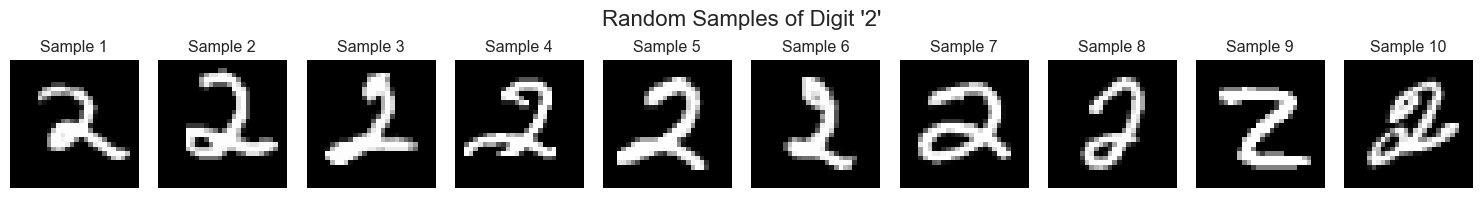


--- Running CCA Geometry Analysis (Mode: LR, PCs=5) ---


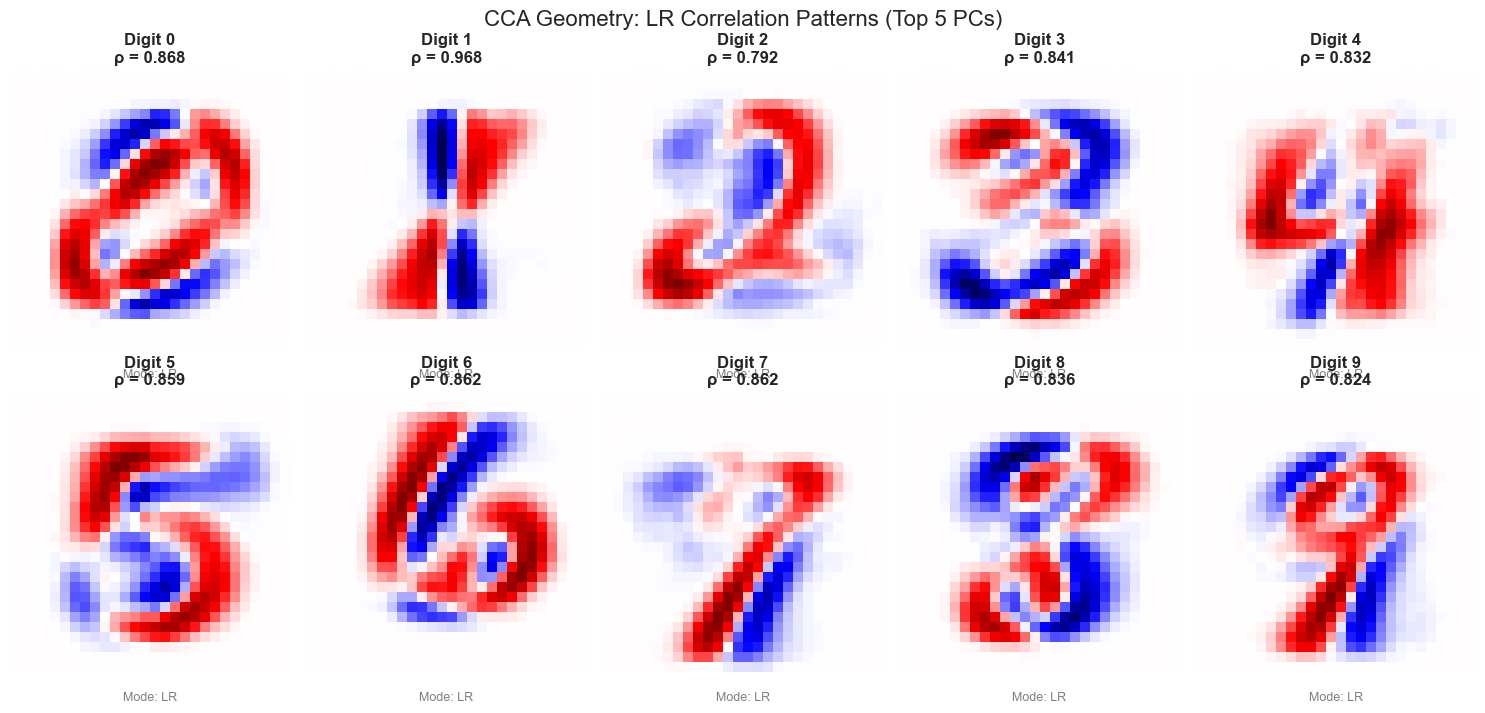


--- Running CCA Geometry Analysis (Mode: TB, PCs=5) ---


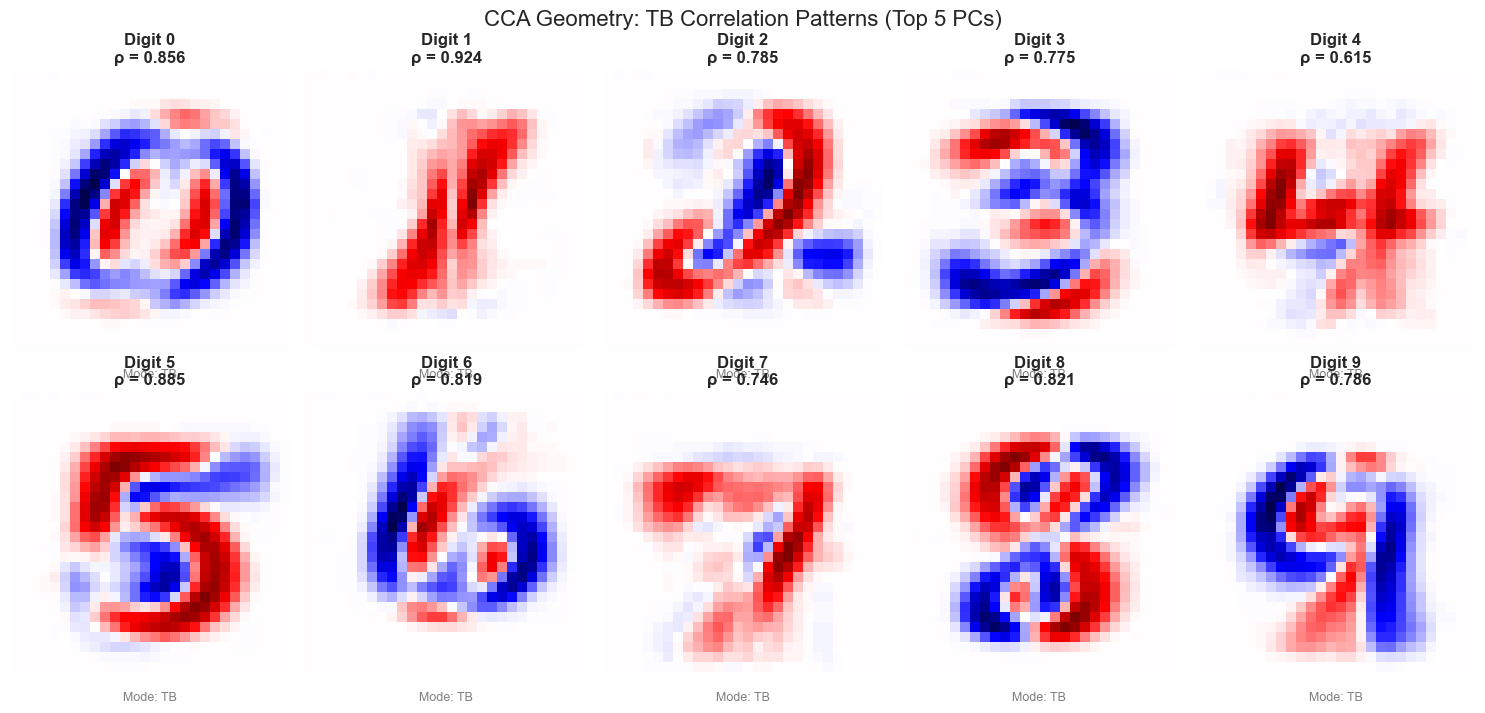


=== CCA Weight Inspection: Digit 2, Mode LR ===
Dominant PC in Left: PC3 (Weight: 0.7489)


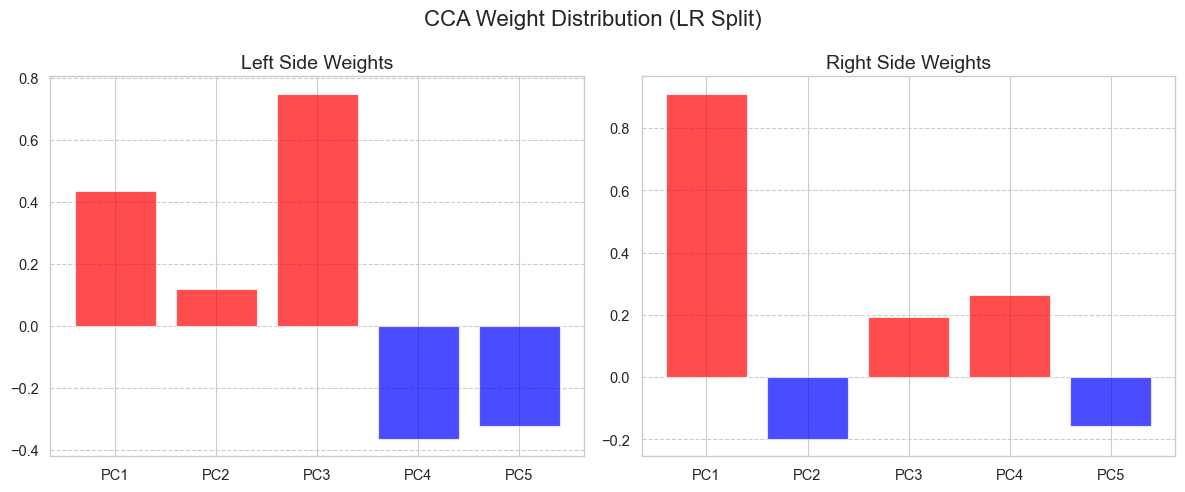


=== CCA Weight Inspection: Digit 2, Mode TB ===
Dominant PC in Top: PC1 (Weight: 0.9545)


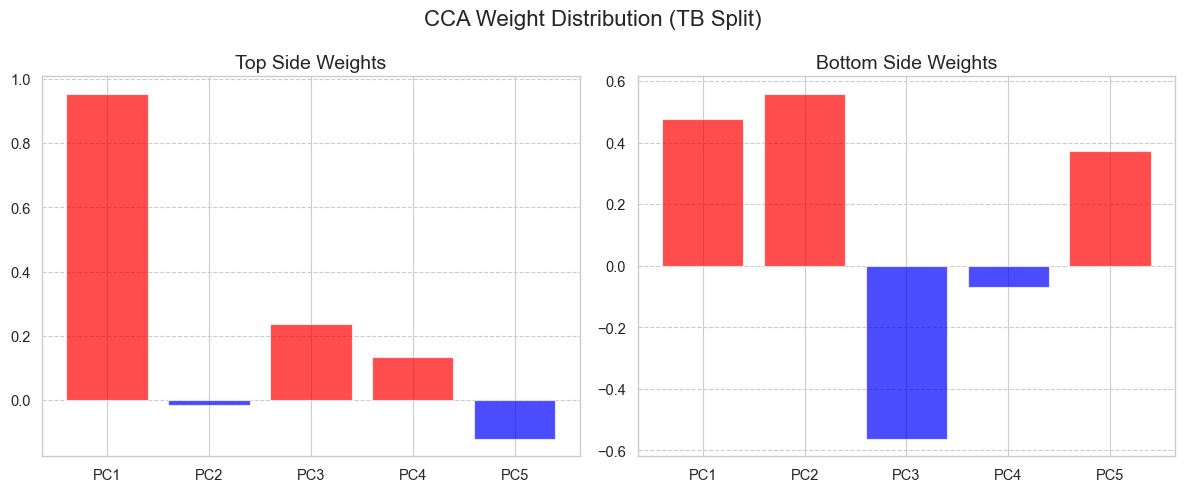


=== Eigen-Image Matrix for Digit '2' ===


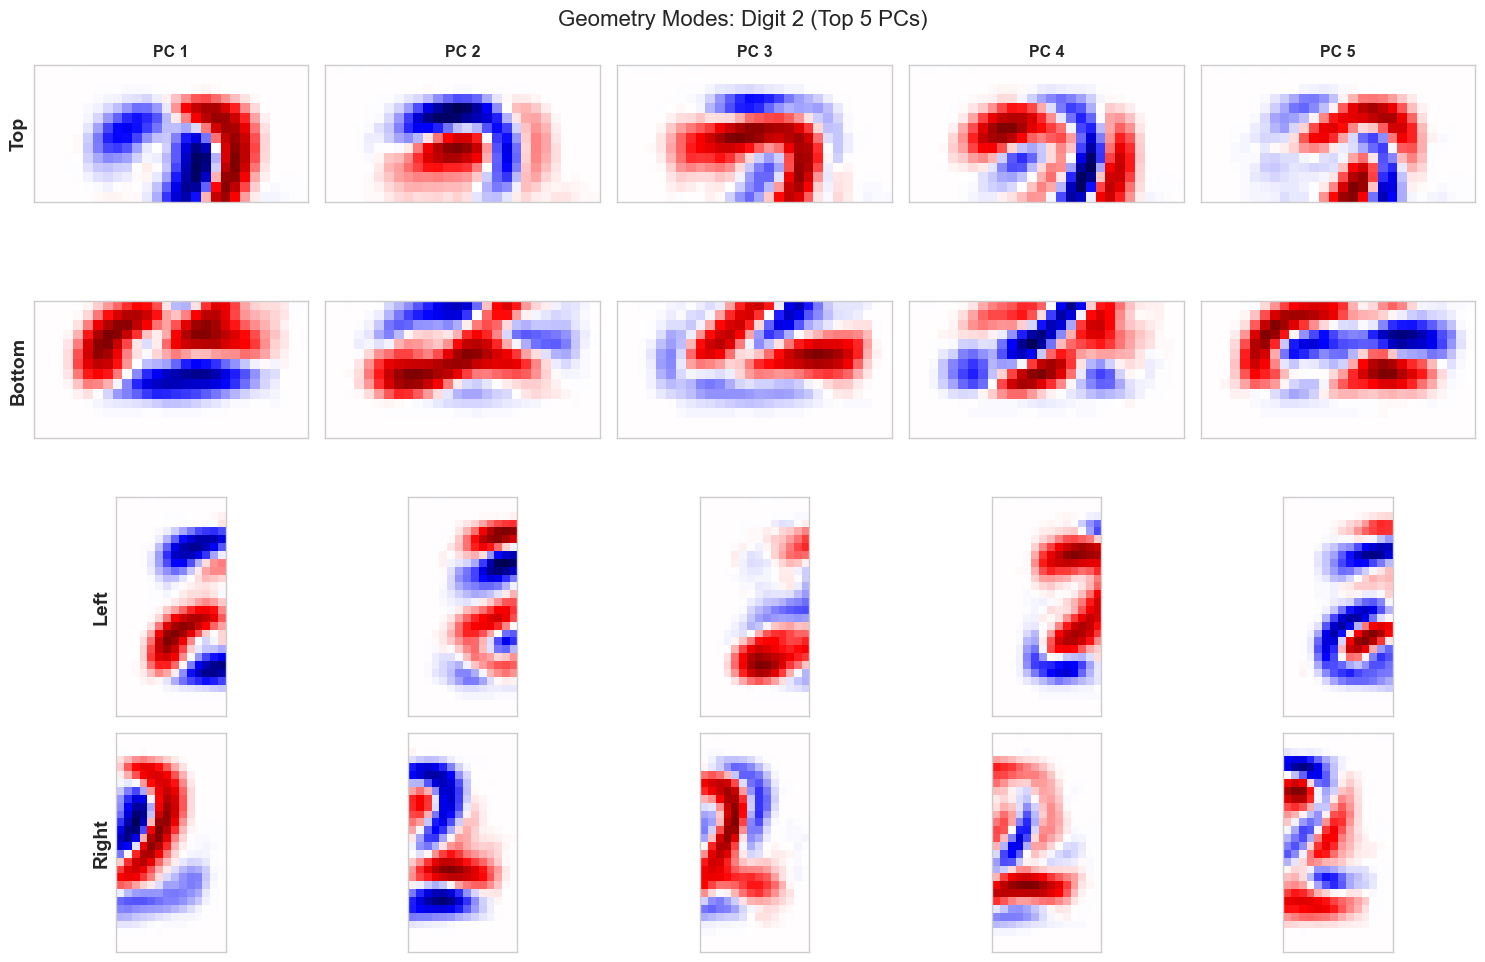


=== CCA Weight Inspection for Digit 2 (Top-Bottom Split) ===

--- CCA Weight Distribution ---
| PC_Index   |   Top_Weight |   Bottom_Weight |
|:-----------|-------------:|----------------:|
| PC1        |       0.9545 |          0.4755 |
| PC2        |      -0.0158 |          0.5592 |
| PC3        |       0.2352 |         -0.5634 |
| PC4        |       0.1351 |         -0.0703 |
| PC5        |      -0.1224 |          0.3726 |

[Observation] The dominant component in Top half is PC1 (Weight: 0.9545)

--- Generating Correlation Summary Barplots (PCA k=5) ---


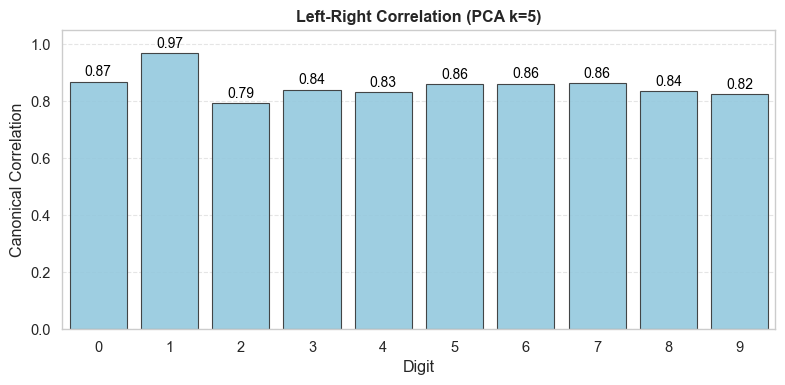

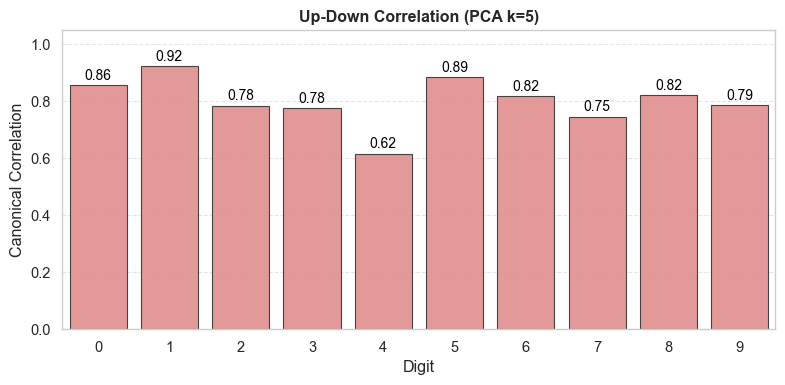


=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===
Target Digit: 7
Dataset Split -> Train: 450, Test: 50
Test Set R^2 Score (Left->Right): 0.3863
Test Set R^2 Score (Top->Bottom): 0.2026
Visualizing Test Sample Index: 23 (from the 50 held-out samples)


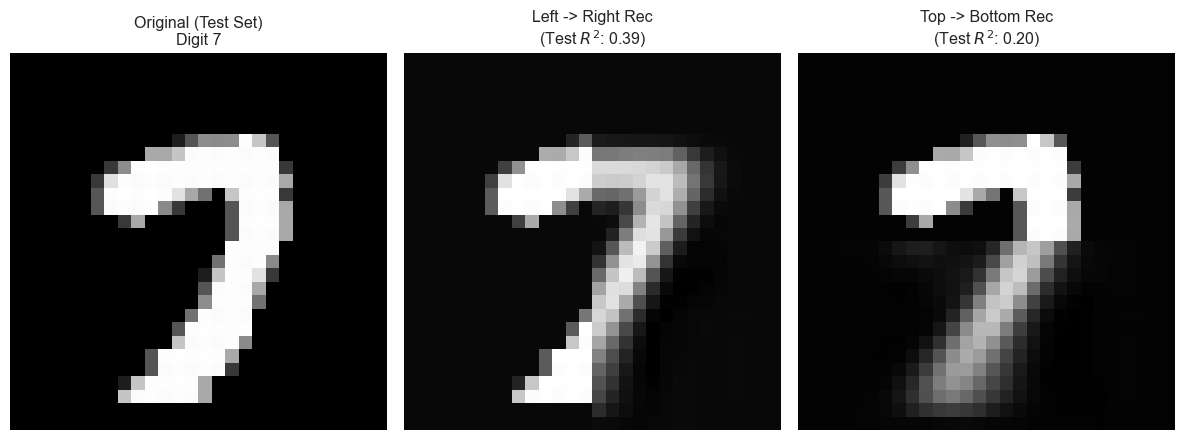

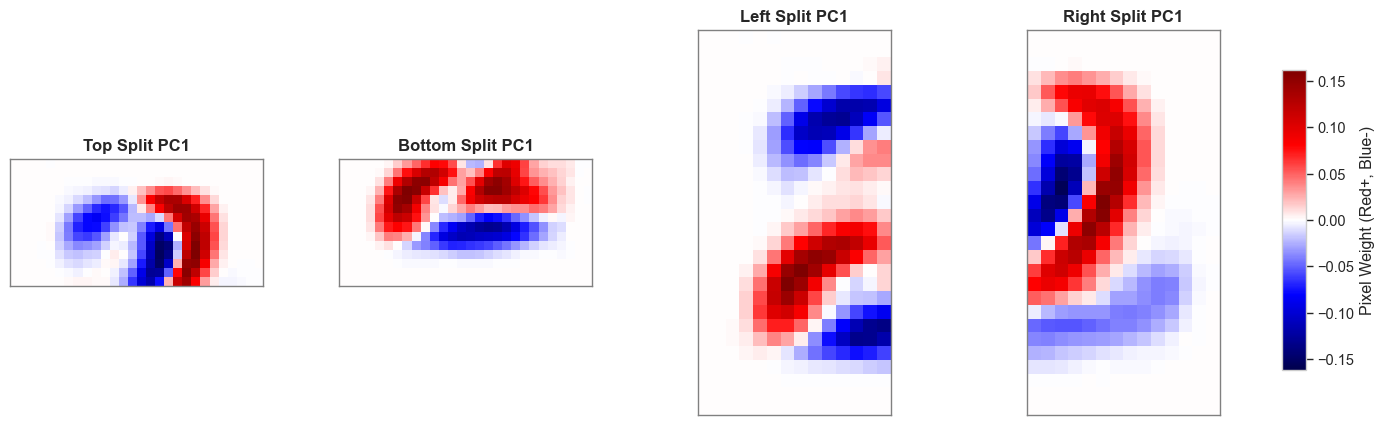

In [18]:
# --- DATA LOADING ---
X, y = load_data_global(DATA_PATH, sample_size=5000) # Do not skip this line

# --------------------------------------------------------
# Run full analysis to see the pictures in my essay.
run_full_analysis(n_components = 5, target_digit = 2)

#### RUNNING INDIVIDUAL FUNCTIONS

Data Loaded. Shape: (5000, 784)


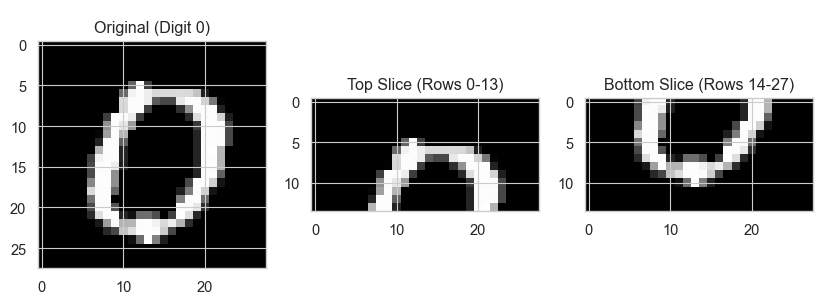

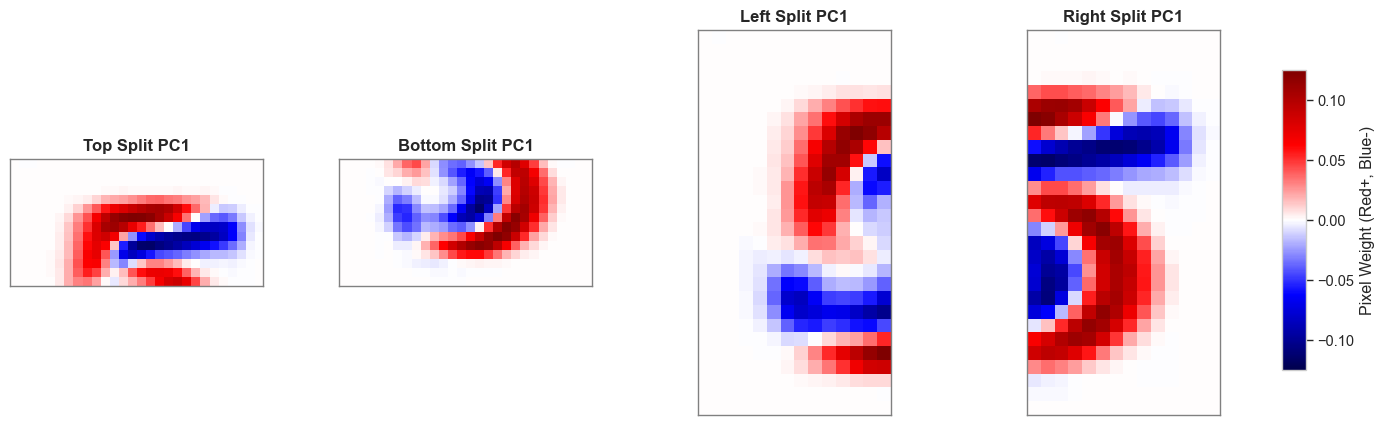

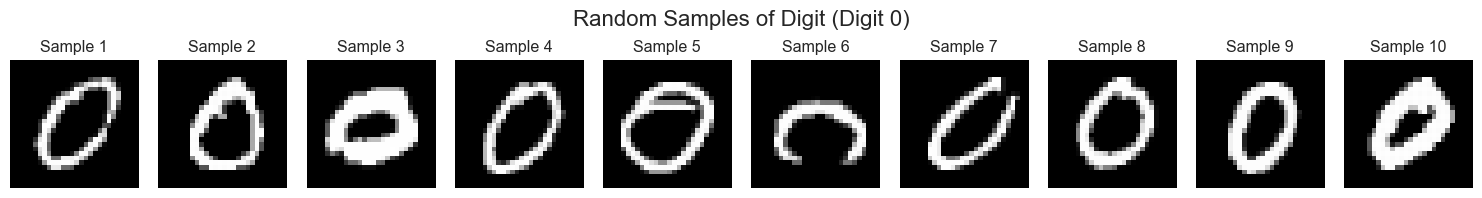


=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===
Target Digit: 1
Dataset Split -> Train: 450, Test: 50
Test Set R^2 Score (Left->Right): -0.9578
Test Set R^2 Score (Top->Bottom): 0.2530
Visualizing Test Sample Index: 35 (from the 50 held-out samples)


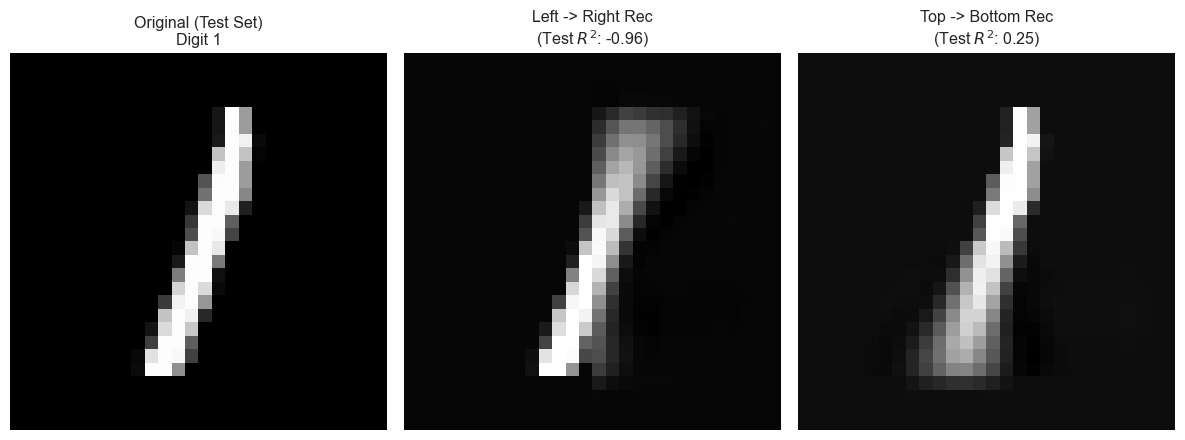


=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===
Target Digit: 6
Dataset Split -> Train: 450, Test: 50
Test Set R^2 Score (Left->Right): 0.2783
Test Set R^2 Score (Top->Bottom): 0.1990
Visualizing Test Sample Index: 29 (from the 50 held-out samples)


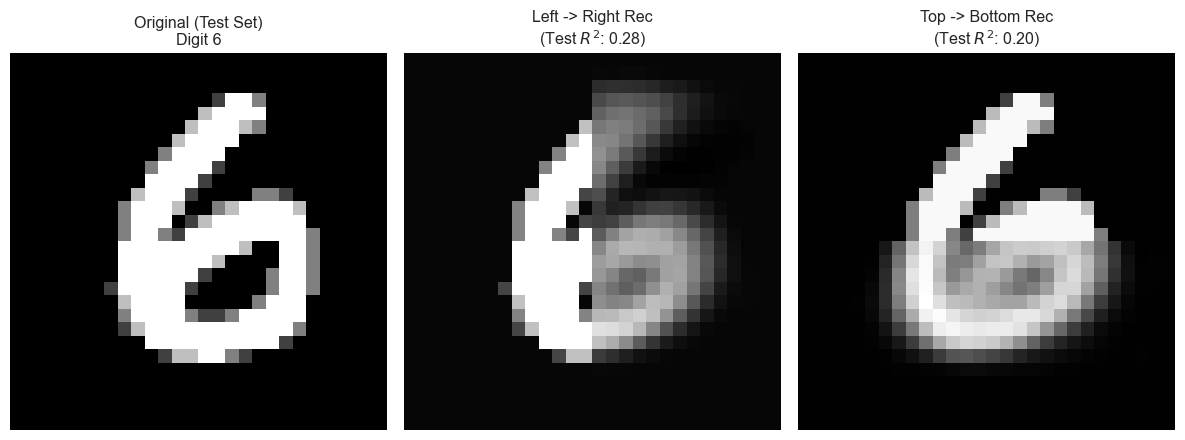


=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===
Target Digit: 7
Dataset Split -> Train: 450, Test: 50
Test Set R^2 Score (Left->Right): 0.0353
Test Set R^2 Score (Top->Bottom): -0.0309
Visualizing Test Sample Index: 4 (from the 50 held-out samples)


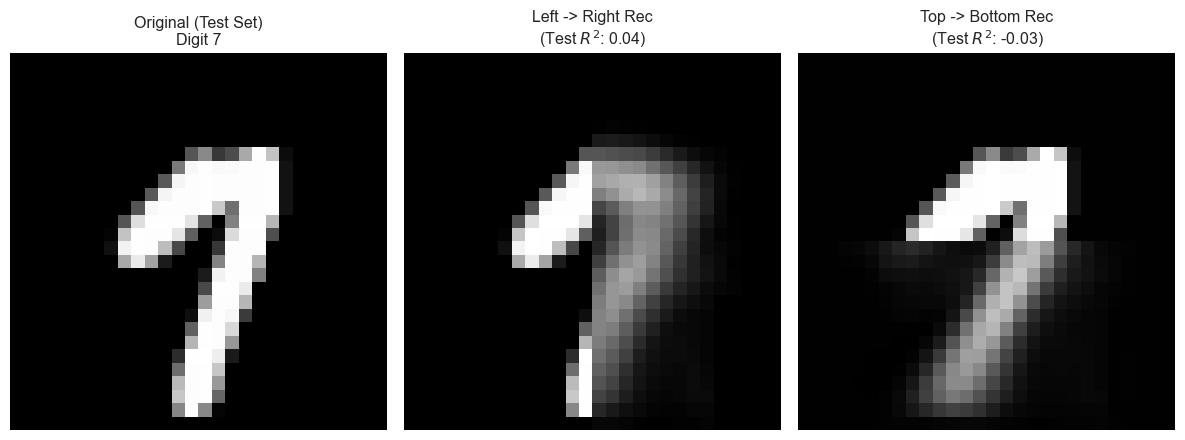


=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===
Target Digit: 4
Dataset Split -> Train: 450, Test: 50
Test Set R^2 Score (Left->Right): 0.1508
Test Set R^2 Score (Top->Bottom): 0.1645
Visualizing Test Sample Index: 40 (from the 50 held-out samples)


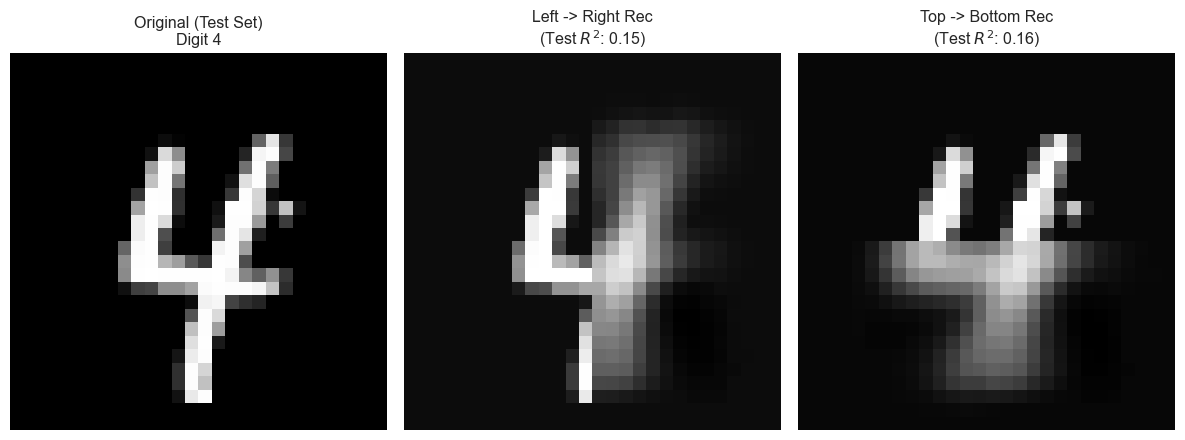


=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===
Target Digit: 8
Dataset Split -> Train: 450, Test: 50
Test Set R^2 Score (Left->Right): 0.1192
Test Set R^2 Score (Top->Bottom): -0.6024
Visualizing Test Sample Index: 44 (from the 50 held-out samples)


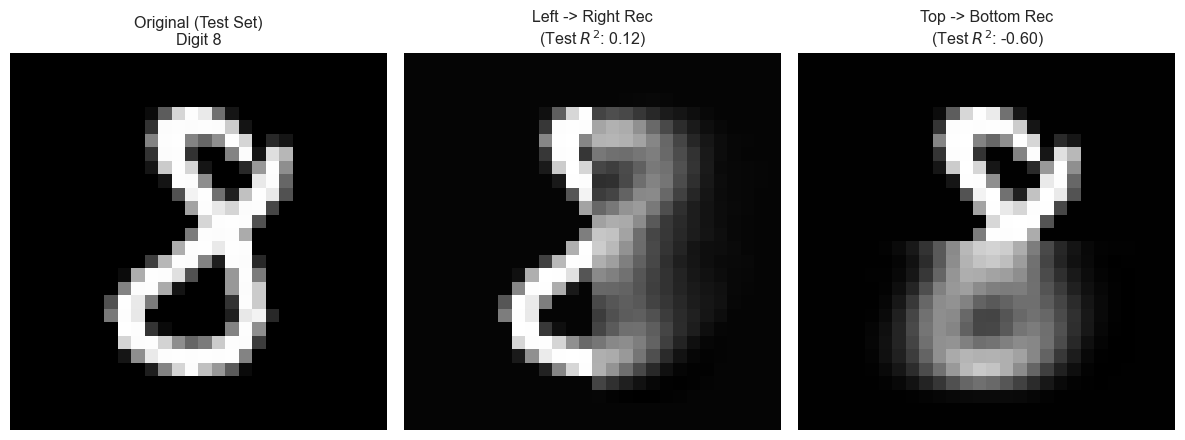


=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===
Target Digit: 0
Dataset Split -> Train: 450, Test: 50
Test Set R^2 Score (Left->Right): 0.3706
Test Set R^2 Score (Top->Bottom): 0.2622
Visualizing Test Sample Index: 25 (from the 50 held-out samples)


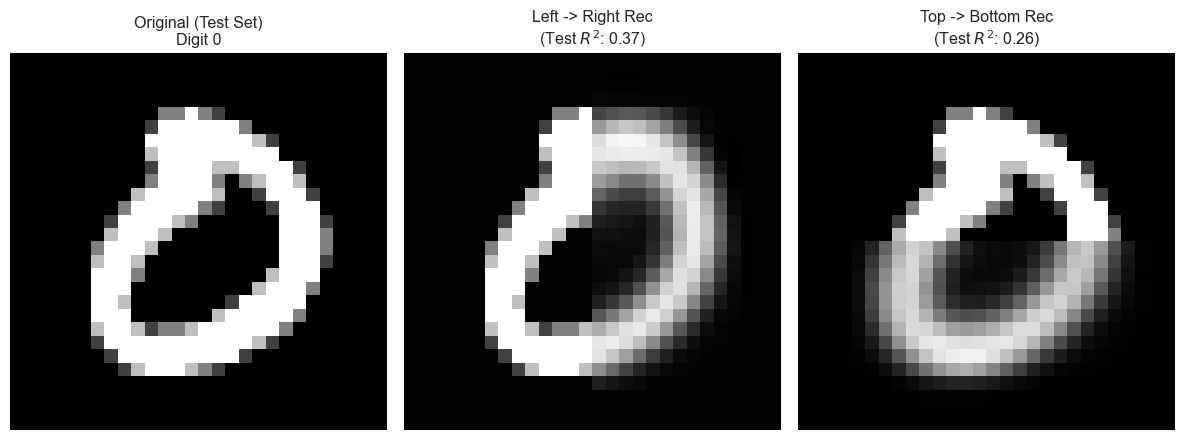


=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===
Target Digit: 5
Dataset Split -> Train: 450, Test: 50
Test Set R^2 Score (Left->Right): 0.3966
Test Set R^2 Score (Top->Bottom): 0.3840
Visualizing Test Sample Index: 43 (from the 50 held-out samples)


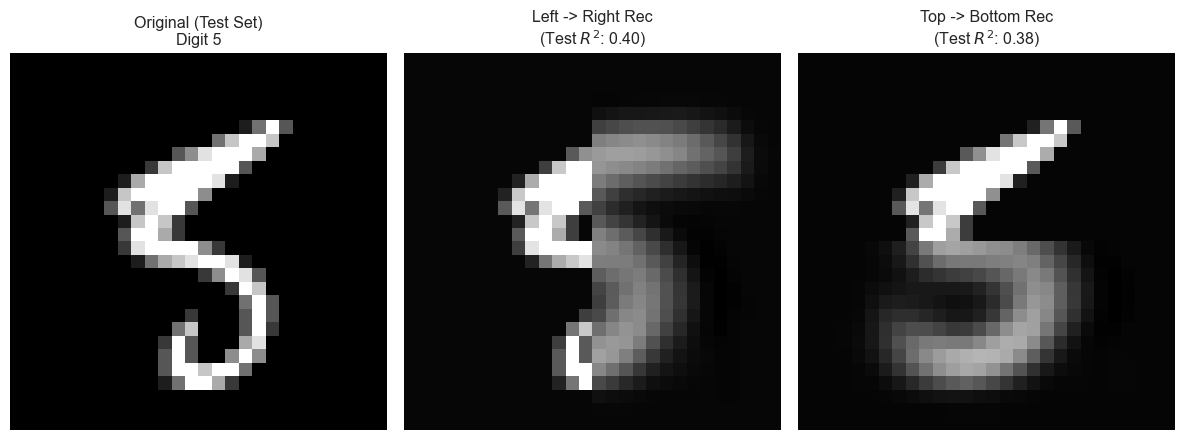


=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===
Target Digit: 2
Dataset Split -> Train: 450, Test: 50
Test Set R^2 Score (Left->Right): 0.2990
Test Set R^2 Score (Top->Bottom): 0.2111
Visualizing Test Sample Index: 11 (from the 50 held-out samples)


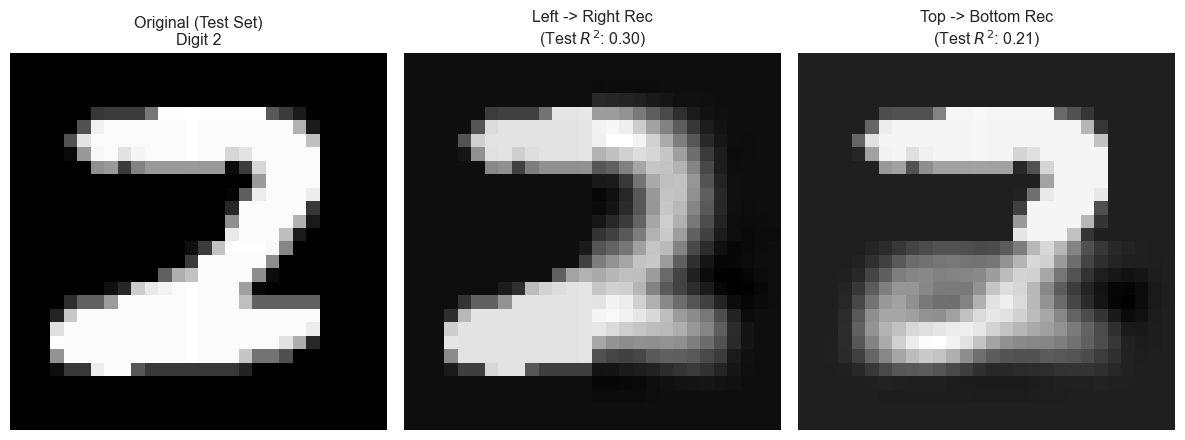


=== Running HD Reconstruction Demo (Split: 450 Train / 50 Test) ===
Target Digit: 9
Dataset Split -> Train: 450, Test: 50
Test Set R^2 Score (Left->Right): 0.2619
Test Set R^2 Score (Top->Bottom): 0.2089
Visualizing Test Sample Index: 4 (from the 50 held-out samples)


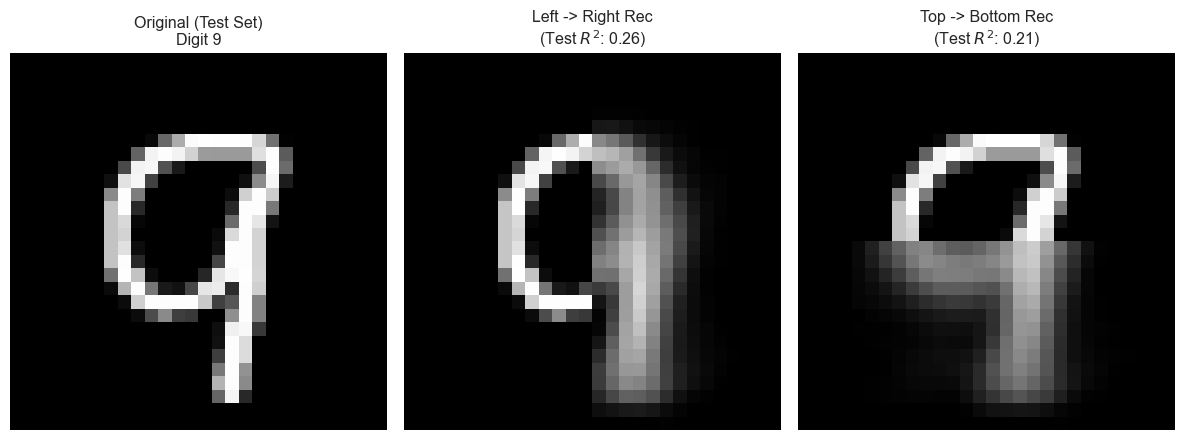


=== Eigen-Image Matrix for Digit '4' ===


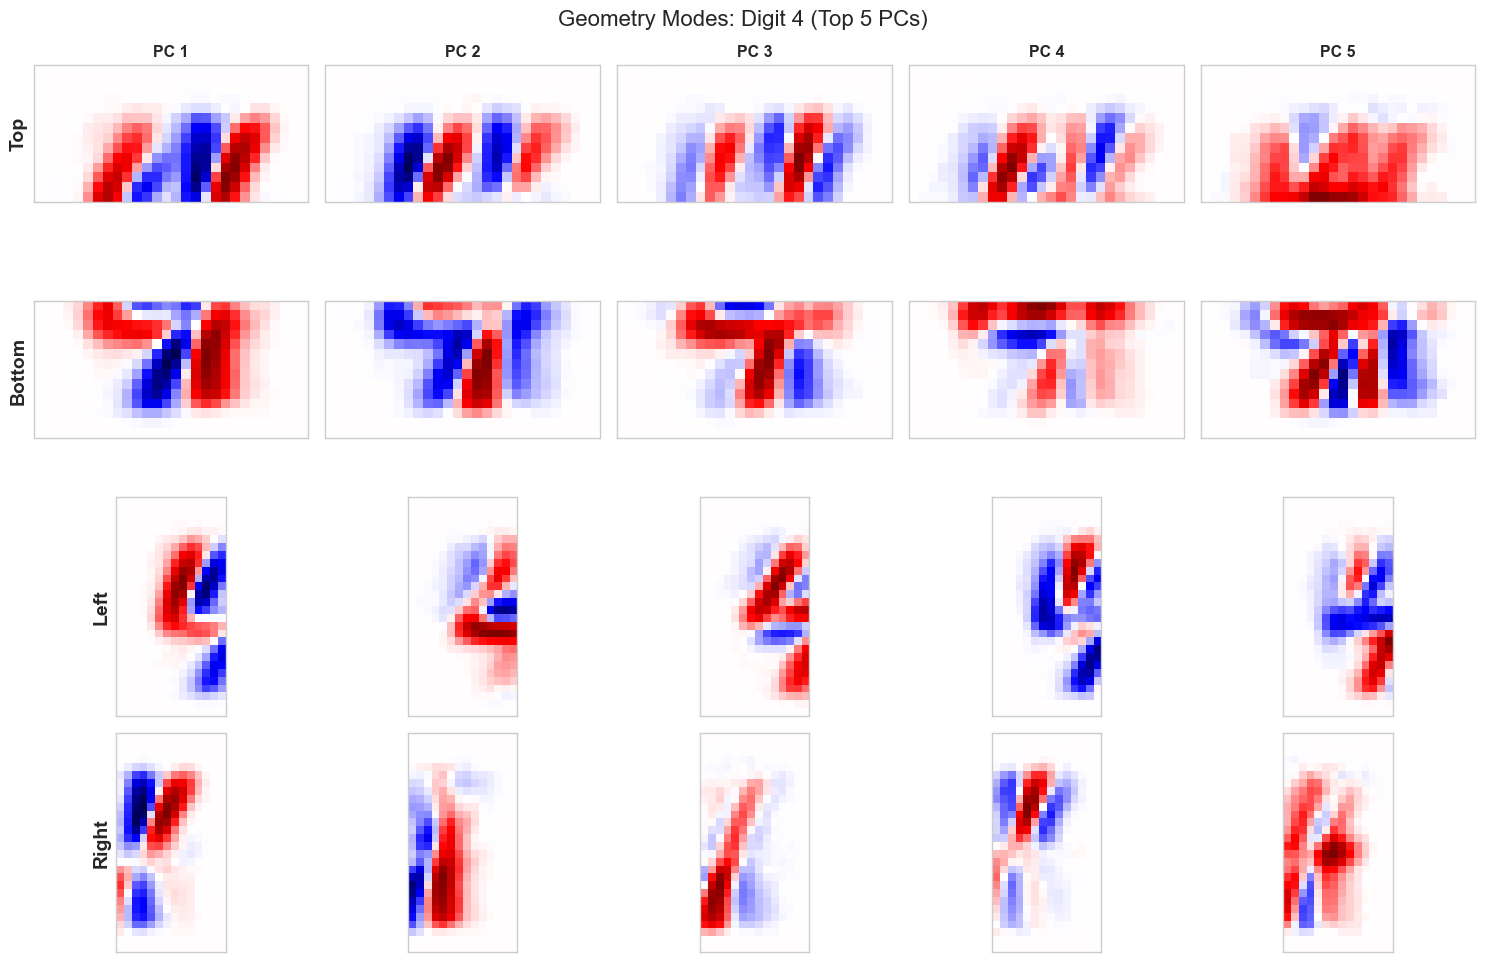


=== Eigen-Image Matrix for Digit '7' ===


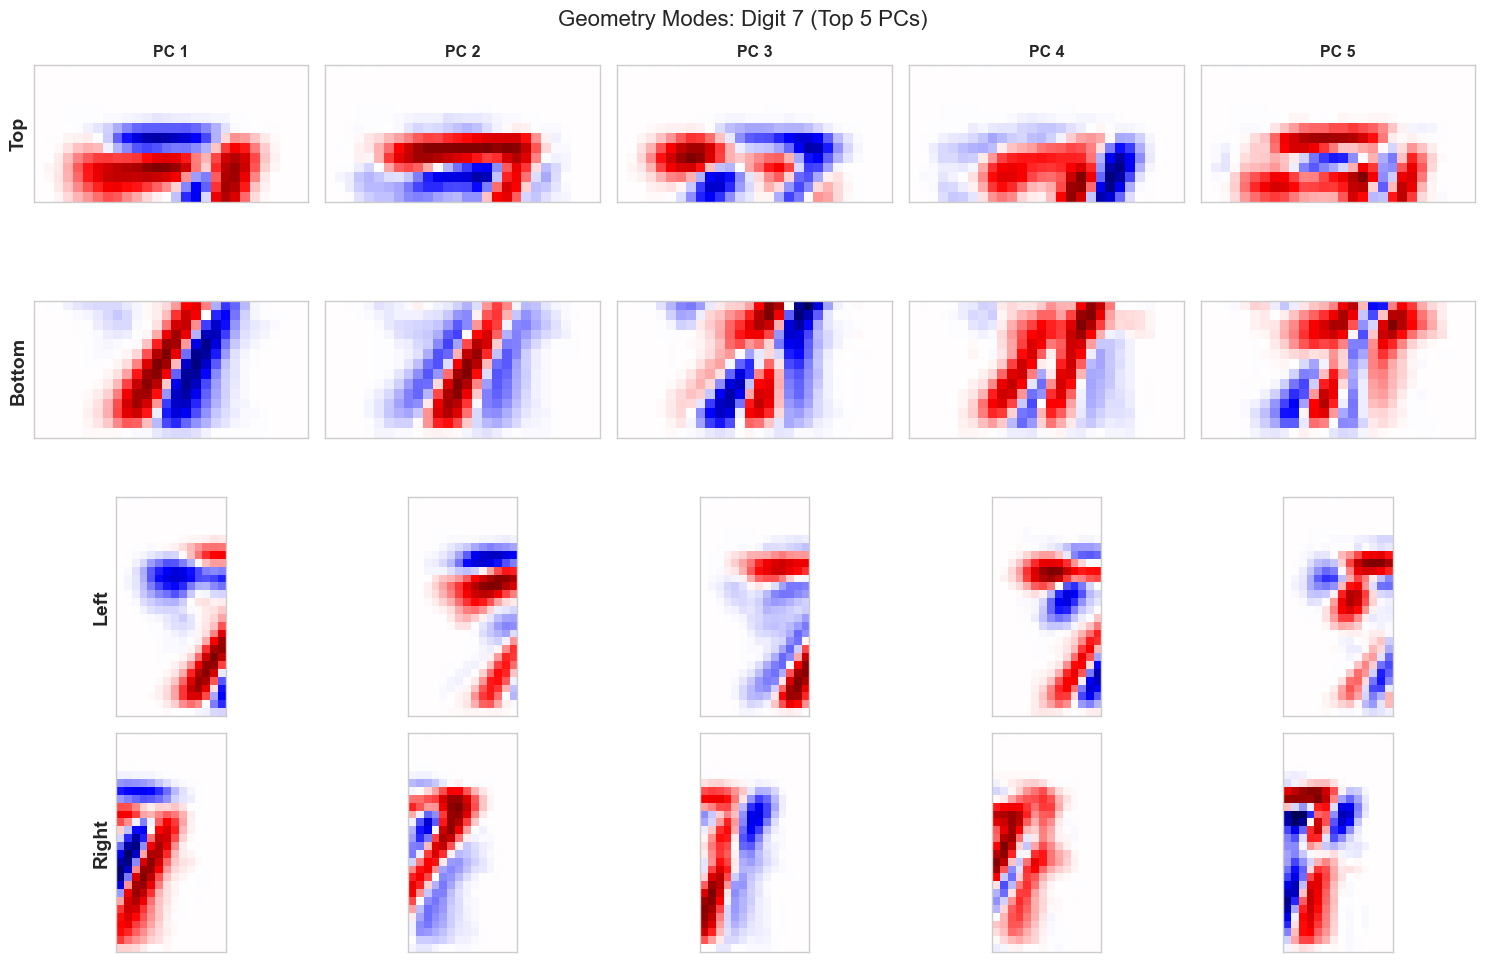

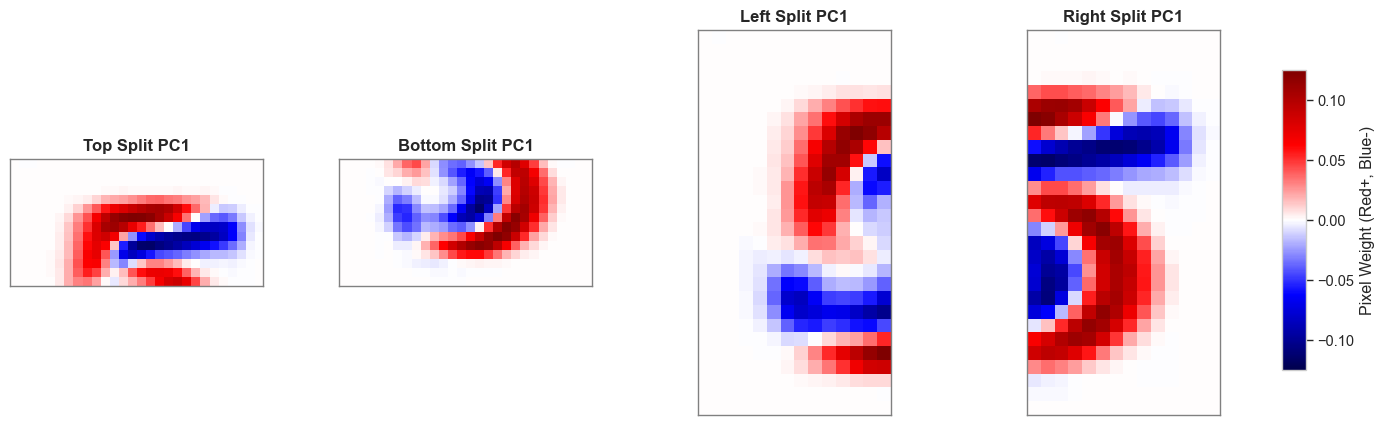


=== CCA Weight Inspection: Digit 1, Mode LR ===
Dominant PC in Left: PC1 (Weight: 0.9026)


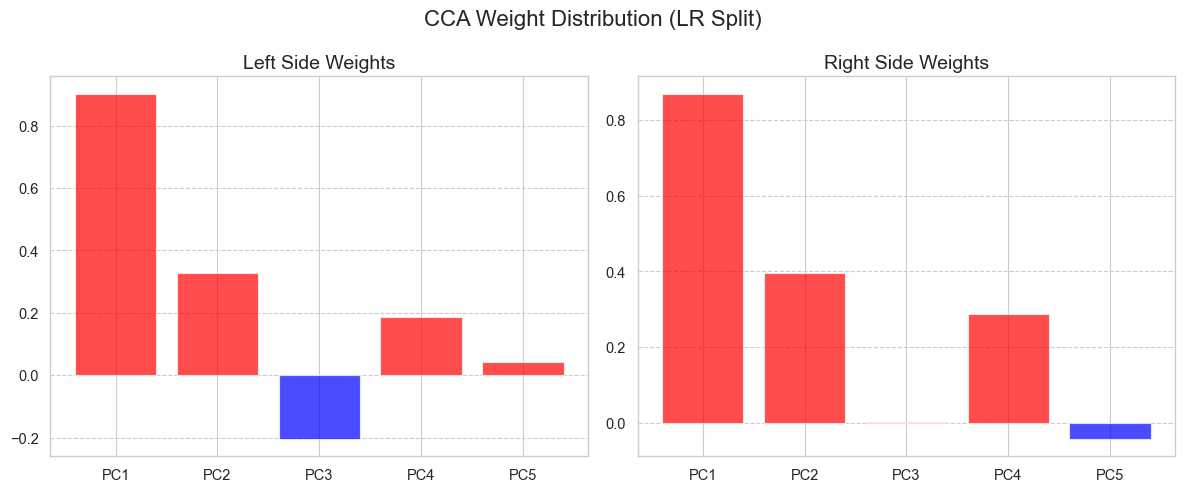


=== CCA Weight Inspection: Digit 1, Mode TB ===
Dominant PC in Top: PC3 (Weight: 0.7528)


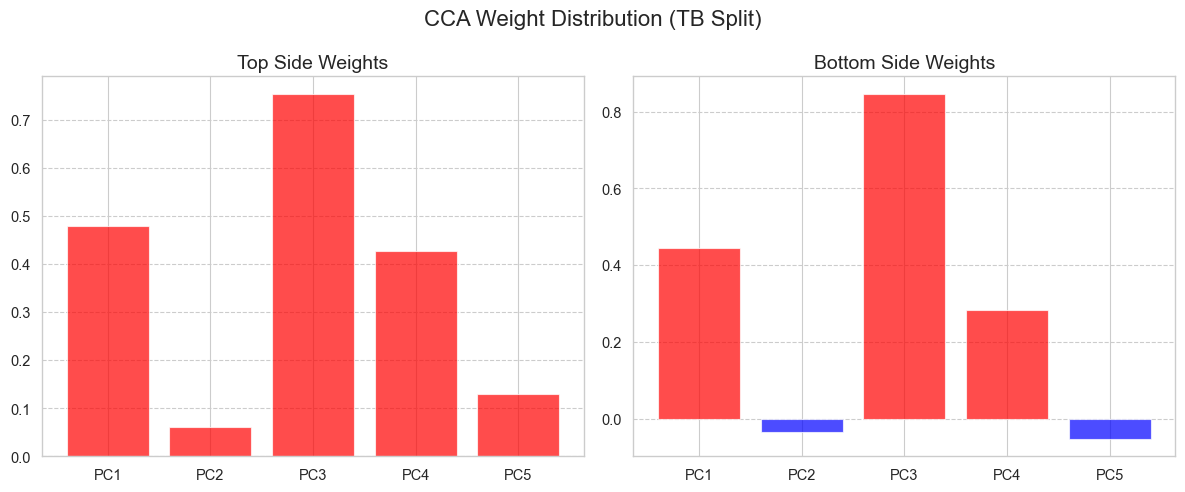


=== CCA Weight Inspection: Digit 5, Mode LR ===
Dominant PC in Left: PC1 (Weight: 0.8647)


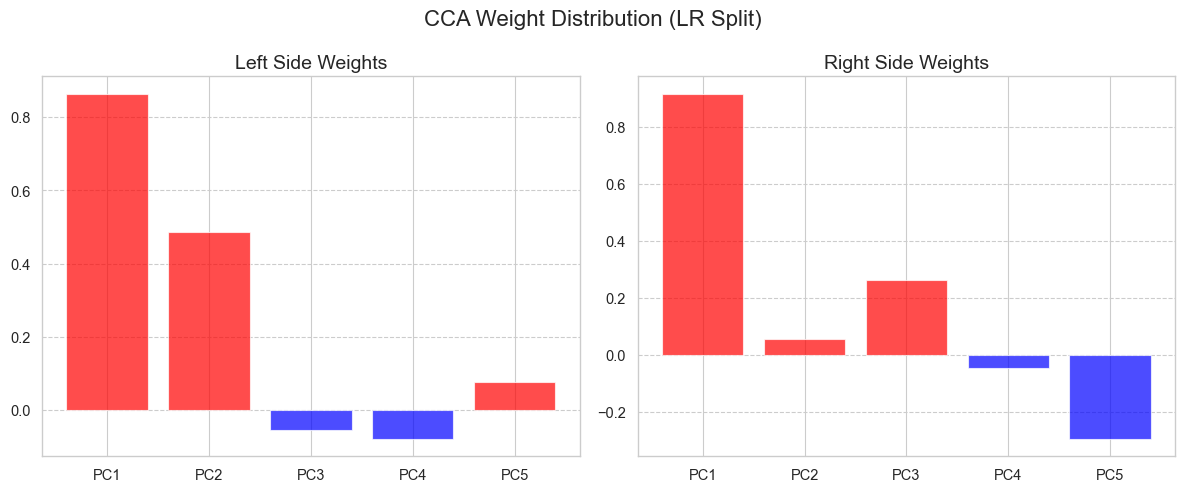


=== CCA Weight Inspection: Digit 5, Mode TB ===
Dominant PC in Top: PC1 (Weight: 0.9021)


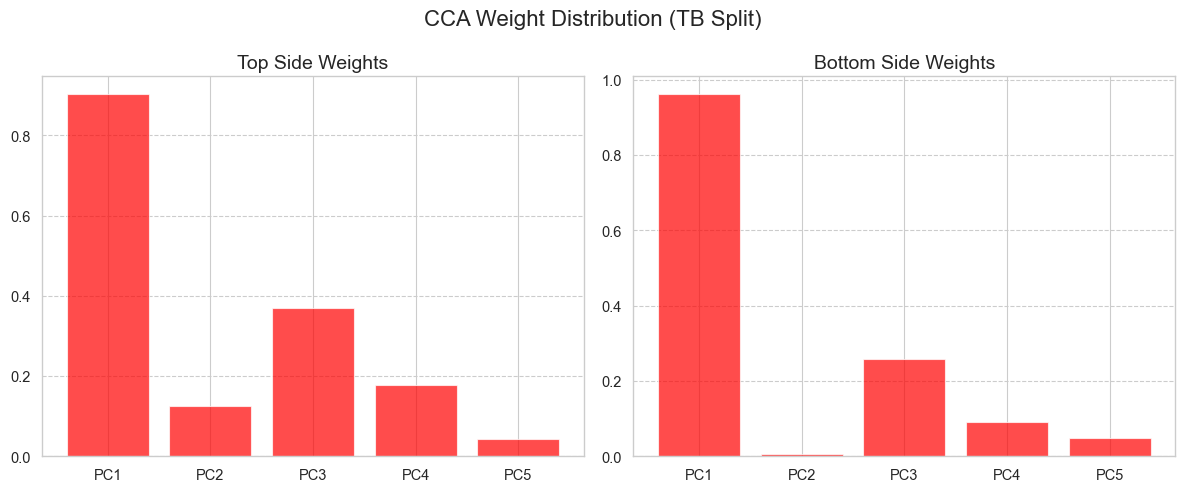


=== CCA Weight Inspection: Digit 7, Mode LR ===
Dominant PC in Left: PC1 (Weight: 0.8857)


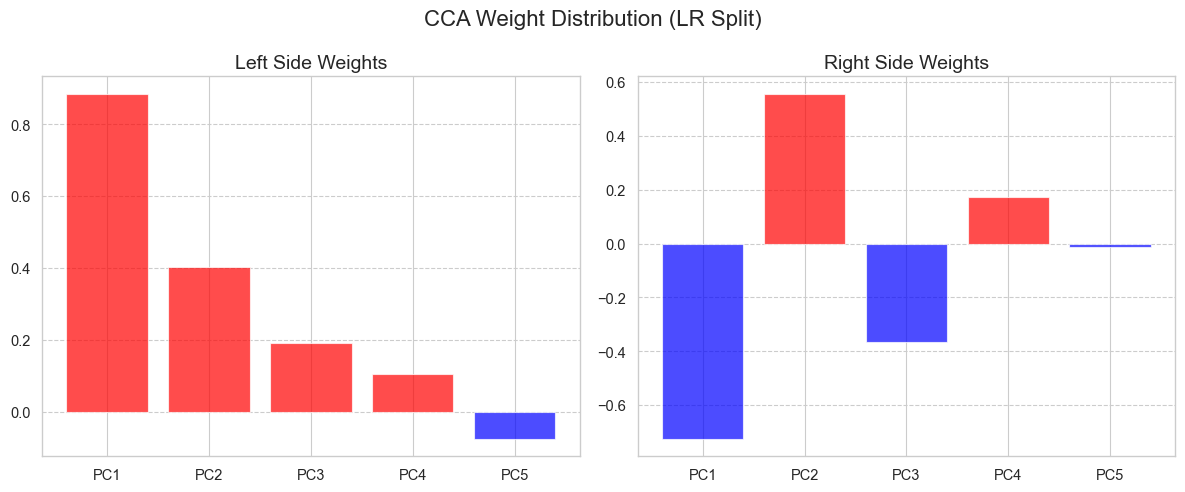


=== CCA Weight Inspection: Digit 7, Mode TB ===
Dominant PC in Top: PC1 (Weight: 0.6815)


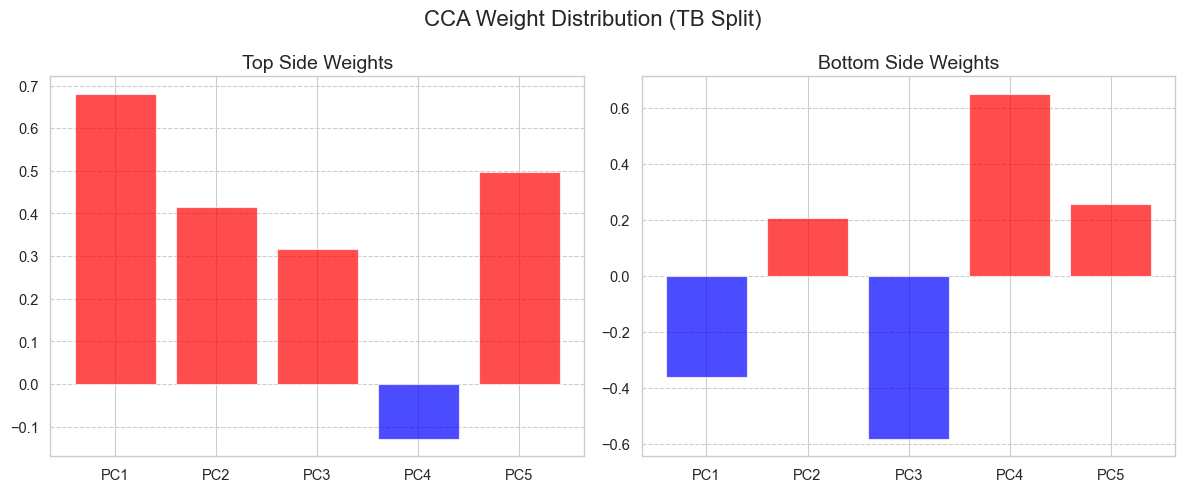


--- Variance Verification (Top 20 PCs) ---
|   Digit | Left_Var   | Right_Var   | Top_Var   | Bottom_Var   |
|--------:|:-----------|:------------|:----------|:-------------|
|       0 | 85.7%      | 83.6%       | 83.3%     | 85.6%        |
|       1 | 91.5%      | 90.0%       | 91.1%     | 90.2%        |
|       2 | 79.7%      | 79.2%       | 82.6%     | 77.3%        |
|       3 | 77.2%      | 81.1%       | 80.1%     | 79.8%        |
|       4 | 83.2%      | 80.4%       | 82.6%     | 81.2%        |
|       5 | 78.4%      | 82.1%       | 81.9%     | 80.0%        |
|       6 | 87.2%      | 80.9%       | 86.2%     | 81.8%        |
|       7 | 82.5%      | 83.6%       | 82.2%     | 84.7%        |
|       8 | 80.4%      | 76.2%       | 78.4%     | 78.9%        |
|       9 | 86.3%      | 81.9%       | 84.1%     | 84.7%        |
Average Variance (Left): 83.2%

--- Generating 4-Way Scree Plots (Top 20 PCs) ---


/var/folders/t2/fny578cd7436sydzf97x4t100000gn/T/ipykernel_3329/4062923585.py:162: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df.set_index("Digit").applymap(lambda x: f"{x:.1%}").to_markdown())


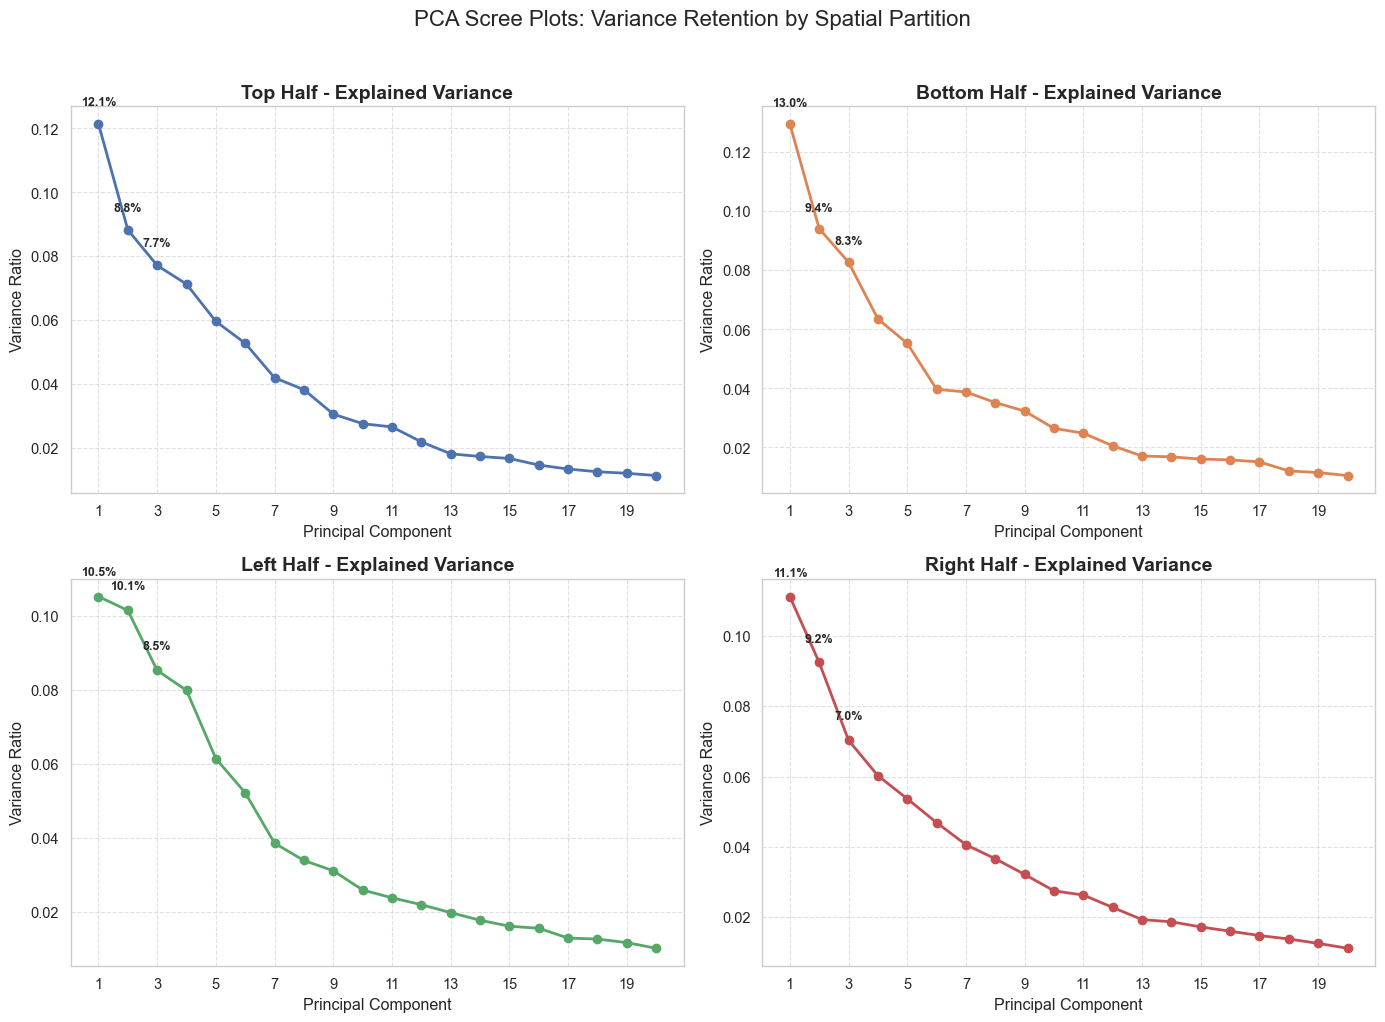

In [20]:
X, y = load_data_global(DATA_PATH, sample_size=5000) # Do not skip this line

# ------------ RUNNING INDIVIDUAL FUNCTIONS ----------------------

display_top_bottom_split(X, y, target_digit = 0)

visualize_digit_pc1_only(X, y, target_digit = 5, n_components = 5)

display_10samples_number(target_digit = 0)

# Reconstruction of Digit Appeared in the Essay.
# Note: not exact same digit's graph
# is generated here as I always draw a digit's sample randomly.
# However, the phenomenon is replicable, if run it for a few times,
# it would be the same as described in my essay.

run_hd_reconstruction_demo(X, y, target_digit=1)
run_hd_reconstruction_demo(X, y, target_digit=6)
run_hd_reconstruction_demo(X, y, target_digit=7)
run_hd_reconstruction_demo(X, y, target_digit=4)
run_hd_reconstruction_demo(X, y, target_digit=8)
run_hd_reconstruction_demo(X, y, target_digit=0)
run_hd_reconstruction_demo(X, y, target_digit=5)
run_hd_reconstruction_demo(X, y, target_digit=2)
run_hd_reconstruction_demo(X, y, target_digit=9)


visualize_pc_matrix_unified(X, y, target_digit = 4, n_components = 5)
visualize_pc_matrix_unified(X, y, target_digit = 7, n_components = 5)

visualize_digit_pc1_only(X, y, target_digit=5, n_components=5)

# Weight Barplot Replication

inspect_cca_weights_unified(X, y, target_digit = 1, n_components = 5, mode='LR')
inspect_cca_weights_unified(X, y, target_digit = 1, n_components = 5, mode='TB')

inspect_cca_weights_unified(X, y, target_digit = 5, n_components = 5, mode='LR')
inspect_cca_weights_unified(X, y, target_digit = 5, n_components = 5, mode='TB')

inspect_cca_weights_unified(X, y, target_digit = 7, n_components = 5, mode='LR')
inspect_cca_weights_unified(X, y, target_digit = 7, n_components = 5, mode='TB')

# Scree Plot
verify_variance_coverage(X, y, n_components=20)
plot_4way_scree(X, n_components=20)

# if you wish to run more, you can copy and paste them here and change
# your parameters as desired.